# 03 — Generate the real-Argon REFPROP Seitz surface

This notebook is independent of the MD cavitation calculation.  It evaluates actual
Argon over a controlled temperature-pressure grid.  Pressure is parameterized as a
fraction of the saturation pressure at each temperature, which keeps the grid in the
superheated-liquid region.

Failed REFPROP/Seitz points remain visible in the output table and are excluded from
plots rather than silently interpolated.


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

MD_REPO = Path.home() / "MDsims"
DATA_DIRECTORY = MD_REPO / "Argon" / "data"
SEITZ_REPO = Path.home() / "SeitzModel"
REFPROP_ROOT = SEITZ_REPO / "REFPROP"
REFPROP_LIBRARY = REFPROP_ROOT / "lib" / "librefprop.so.2.30"

if str(REFPROP_ROOT) not in sys.path:
    sys.path.insert(0, str(REFPROP_ROOT))

from ctREFPROP.ctREFPROP import REFPROPFunctionLibrary
from SeitzModel import SeitzModel

rp = REFPROPFunctionLibrary(str(REFPROP_LIBRARY))
rp.SETPATHdll(str(REFPROP_ROOT))
ierr, herr = rp.SETUPdll(
    1,
    str(REFPROP_ROOT / "FLUIDS" / "ARGON.FLD"),
    str(REFPROP_ROOT / "FLUIDS" / "HMX.BNC"),
    "DEF",
)
assert ierr == 0, herr
print("REFPROP version:", rp.RPVersion())


REFPROP version: 10.0.0.02


## Define and inspect the physical grid


In [2]:
temperatures_K = np.arange(90.0, 141.0, 5.0)
pressure_fractions = np.array([0.10, 0.25, 0.40, 0.55, 0.70, 0.85])

saturation_rows = []
for temperature_K in temperatures_K:
    sat = rp.SATTdll(float(temperature_K), [1.0], 1)
    saturation_rows.append({
        "temperature_K": temperature_K,
        "Pvap_kPa": sat.P,
        "Pvap_bar": sat.P / 100.0,
        "rho_liquid_mol_L": sat.Dl,
        "rho_vapor_mol_L": sat.Dv,
        "ierr": sat.ierr,
        "message": sat.herr,
    })
saturation_table = pd.DataFrame(saturation_rows)
saturation_table


,temperature_K,Pvap_kPa,Pvap_bar,rho_liquid_mol_L,rho_vapor_mol_L,ierr,message
0,90.0,133.506066,1.335061,34.510524,0.186146,0,
1,95.0,213.046956,2.130470,33.713097,0.286250,0,
2,100.0,323.767186,3.237672,32.885204,0.422018,0,
3,105.0,472.238501,4.722385,32.020104,0.601257,0,
4,110.0,665.260829,6.652608,31.109715,0.833263,0,
5,115.0,909.810223,9.098102,30.143740,1.129622,0,
6,120.0,1213.037739,12.130377,29.108281,1.505568,0,
7,125.0,1582.330893,15.823309,27.983380,1.982425,0,
8,130.0,2025.461331,20.254613,26.738098,2.592396,0,
9,135.0,2550.872136,25.508721,25.319519,3.389279,0,


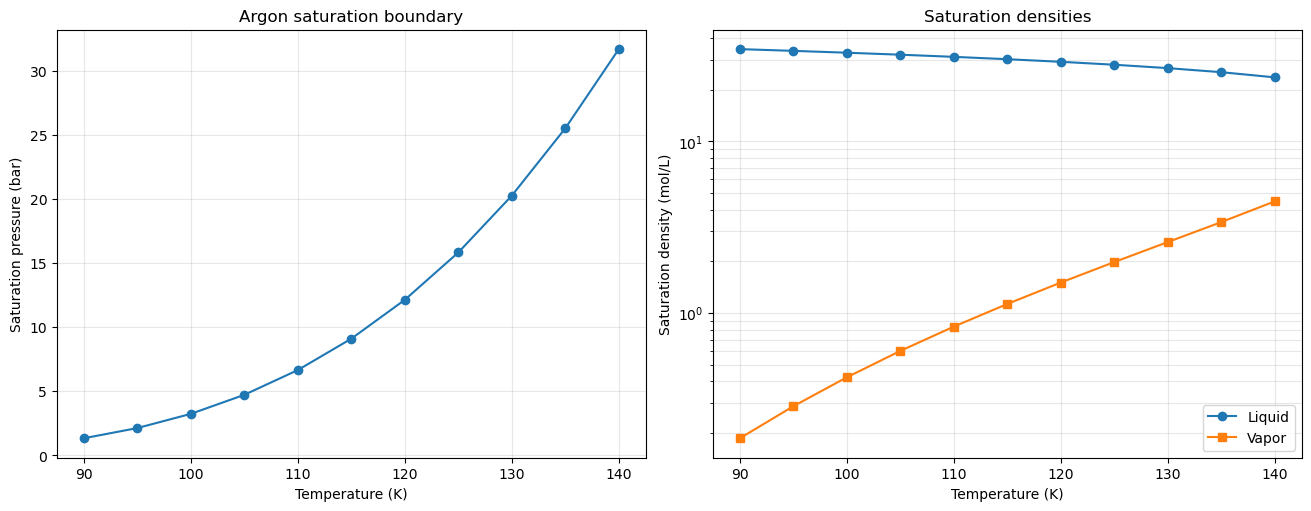

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
axes[0].plot(saturation_table["temperature_K"], saturation_table["Pvap_bar"], "o-")
axes[0].set(xlabel="Temperature (K)", ylabel="Saturation pressure (bar)", title="Argon saturation boundary")
axes[0].grid(alpha=0.3)
axes[1].plot(saturation_table["temperature_K"], saturation_table["rho_liquid_mol_L"], "o-", label="Liquid")
axes[1].plot(saturation_table["temperature_K"], saturation_table["rho_vapor_mol_L"], "s-", label="Vapor")
axes[1].set(xlabel="Temperature (K)", ylabel="Saturation density (mol/L)", title="Saturation densities", yscale="log")
axes[1].legend()
axes[1].grid(alpha=0.3, which="both")
plt.show()


In [4]:
grid_rows = []
for row in saturation_table.itertuples(index=False):
    for fraction in pressure_fractions:
        pressure_bar = fraction * row.Pvap_bar
        grid_rows.append({
            "temperature_K": row.temperature_K,
            "temperature_C": row.temperature_K - 273.15,
            "pressure_fraction_of_Pvap": fraction,
            "pressure_bar": pressure_bar,
            "pressure_psia": pressure_bar * 14.5037738,
            "Pvap_bar_direct": row.Pvap_bar,
        })
grid = pd.DataFrame(grid_rows)
print("Grid points:", len(grid))
grid


Grid points: 66


,temperature_K,temperature_C,pressure_fraction_of_Pvap,pressure_bar,pressure_psia,Pvap_bar_direct
0,90.0,-183.15,0.10,0.133506,1.936342,1.335061
1,90.0,-183.15,0.25,0.333765,4.840854,1.335061
2,90.0,-183.15,0.40,0.534024,7.745367,1.335061
3,90.0,-183.15,0.55,0.734283,10.649880,1.335061
4,90.0,-183.15,0.70,0.934542,13.554392,1.335061
...,...,...,...,...,...,...
61,140.0,-133.15,0.25,7.920568,114.878124,31.682271
62,140.0,-133.15,0.40,12.672908,183.804998,31.682271
63,140.0,-133.15,0.55,17.425249,252.731872,31.682271
64,140.0,-133.15,0.70,22.177590,321.658746,31.682271


## Evaluate SeitzModel at every paired temperature-pressure point


In [5]:
reference = SeitzModel(
    grid["pressure_psia"].to_numpy(dtype=float),
    grid["temperature_C"].to_numpy(dtype=float),
    "ARGON",
    [1.0],
)

fields = {
    "Q_keV": reference.Q,
    "Rc_nm": reference.Rc,
    "Pvap_psia": reference.Pvap,
    "Pbub_psia": reference.Pbub,
    "Rho_l_g_cc": reference.Rho_l,
    "Rho_b_g_cc": reference.Rho_b,
    "Sigma_N_m": reference.Sigma,
    "P_err_psia": reference.P_err,
    "G_err_J_kg": reference.G_err,
    "iterations": reference.interp_iterations,
    "errID": reference.errID,
}
for name, values in fields.items():
    grid[name] = np.asarray(values, dtype=object)

numeric = [name for name in fields if name != "errID"]
grid[numeric] = grid[numeric].apply(pd.to_numeric, errors="coerce")
grid["valid"] = (
    grid["errID"].isna()
    & grid["Q_keV"].gt(0)
    & grid["Rc_nm"].gt(0)
    & grid["Pvap_psia"].gt(grid["pressure_psia"])
    & grid["Pbub_psia"].gt(grid["pressure_psia"])
)

print("Valid points:", int(grid["valid"].sum()), "/", len(grid))
grid


Valid points: 62 / 66


,temperature_K,temperature_C,pressure_fraction_of_Pvap,pressure_bar,pressure_psia,Pvap_bar_direct,Q_keV,Rc_nm,Pvap_psia,Pbub_psia,Rho_l_g_cc,Rho_b_g_cc,Sigma_N_m,P_err_psia,G_err_J_kg,iterations,errID,valid
0,90.0,-183.15,0.10,0.133506,1.936342,1.335061,322.404405,198.658109,19.363418,19.269643,1.378245,0.007399,0.011871,-4.349381e-11,0.000157,28.0,None,True
1,90.0,-183.15,0.25,0.333765,4.840854,1.335061,534.031345,238.390248,19.363418,19.285241,1.378309,0.007405,0.011871,1.079197e-11,0.000040,19.0,None,True
2,90.0,-183.15,0.40,0.534024,7.745367,1.335061,997.989197,297.988455,19.363418,19.300851,1.378372,0.007411,0.011871,-3.876330e-11,0.000021,14.0,None,True
3,90.0,-183.15,0.55,0.734283,10.649880,1.335061,2258.945319,397.318801,19.363418,19.316474,1.378436,0.007417,0.011871,3.306021e-11,0.000007,11.0,None,True
4,90.0,-183.15,0.70,0.934542,13.554392,1.335061,7264.320365,595.979493,19.363418,19.332110,1.378499,0.007424,0.011871,1.288194e-11,0.000005,8.0,None,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61,140.0,-133.15,0.25,7.920568,114.878124,31.682271,NaN,NaN,459.512494,NaN,NaN,NaN,NaN,NaN,NaN,NaN,202.2,False
62,140.0,-133.15,0.40,12.672908,183.804998,31.682271,NaN,NaN,459.512494,NaN,NaN,NaN,NaN,NaN,NaN,NaN,202.2,False
63,140.0,-133.15,0.55,17.425249,252.731872,31.682271,NaN,NaN,459.512494,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-704.8,False
64,140.0,-133.15,0.70,22.177590,321.658746,31.682271,0.042556,3.484548,459.512494,434.389202,0.899368,0.158953,0.001354,-1.714844e-12,0.000012,20.0,None,True


## Visualize the real-Argon Seitz surface


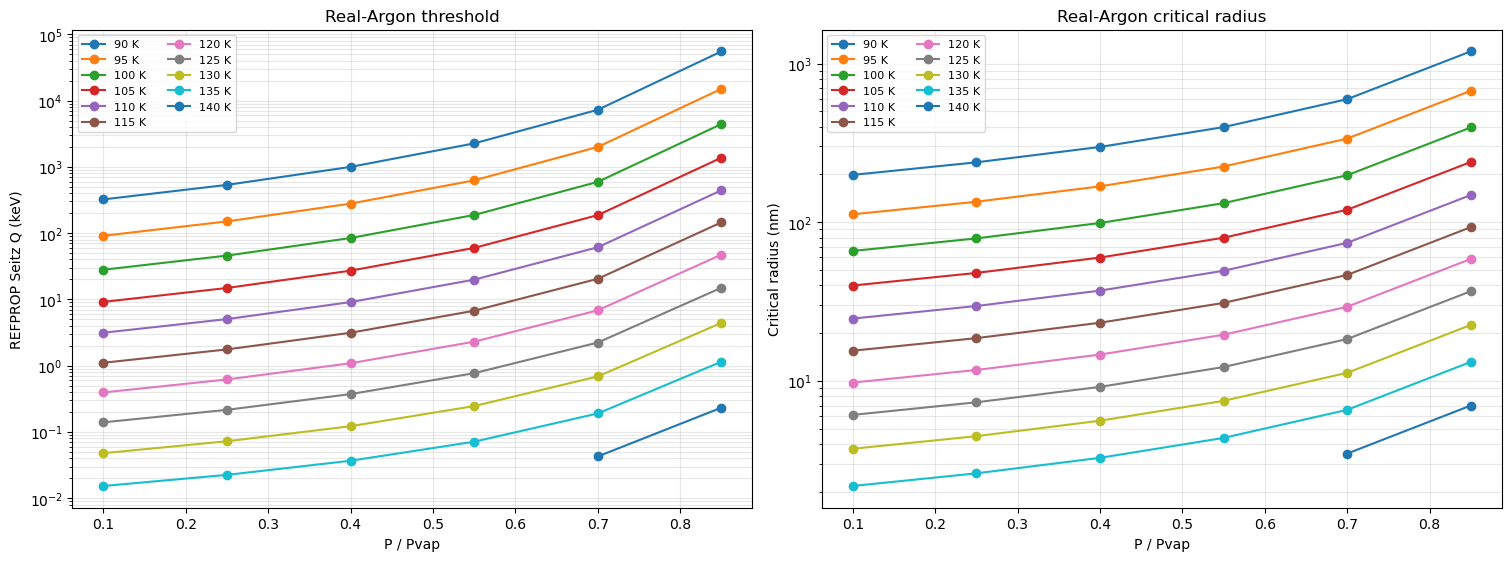

In [6]:
valid = grid.loc[grid["valid"]].copy()
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), constrained_layout=True)
for temperature, group in valid.groupby("temperature_K"):
    group = group.sort_values("pressure_fraction_of_Pvap")
    axes[0].plot(group["pressure_fraction_of_Pvap"], group["Q_keV"], "o-", label=f"{temperature:g} K")
    axes[1].plot(group["pressure_fraction_of_Pvap"], group["Rc_nm"], "o-", label=f"{temperature:g} K")
axes[0].set(xlabel="P / Pvap", ylabel="REFPROP Seitz Q (keV)", title="Real-Argon threshold", yscale="log")
axes[1].set(xlabel="P / Pvap", ylabel="Critical radius (nm)", title="Real-Argon critical radius", yscale="log")
for axis in axes:
    axis.legend(ncol=2, fontsize=8)
    axis.grid(alpha=0.3, which="both")
plt.show()


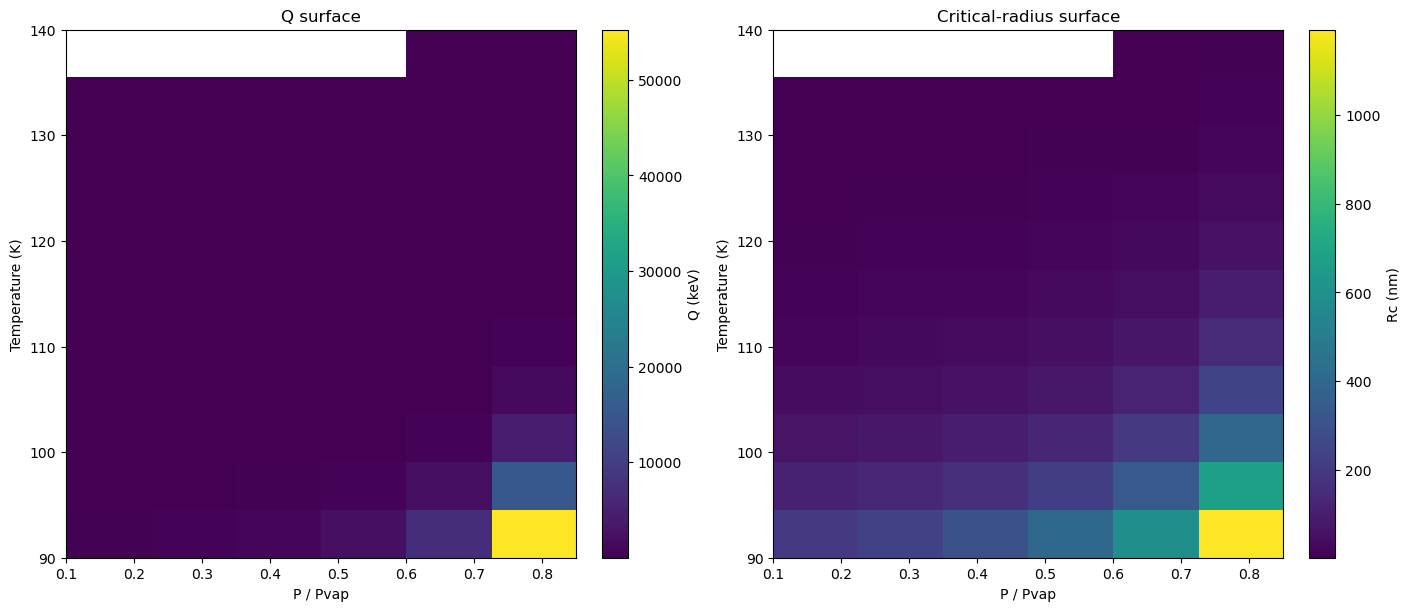

In [7]:
q_surface = valid.pivot(index="temperature_K", columns="pressure_fraction_of_Pvap", values="Q_keV")
rc_surface = valid.pivot(index="temperature_K", columns="pressure_fraction_of_Pvap", values="Rc_nm")

fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)
for axis, surface, title, label in [
    (axes[0], q_surface, "Q surface", "Q (keV)"),
    (axes[1], rc_surface, "Critical-radius surface", "Rc (nm)"),
]:
    image = axis.imshow(surface.to_numpy(), origin="lower", aspect="auto",
                        extent=[surface.columns.min(), surface.columns.max(),
                                surface.index.min(), surface.index.max()])
    axis.set(xlabel="P / Pvap", ylabel="Temperature (K)", title=title)
    fig.colorbar(image, ax=axis, label=label)
plt.show()


In [8]:
output_path = DATA_DIRECTORY / "argon_refprop_seitz_grid.csv"
grid.to_csv(output_path, index=False)
print("Saved:", output_path)


Saved: /home/pnichols/MDsims/Argon/data/argon_refprop_seitz_grid.csv
